# Amazon Delivery Kaggle Data EDA & Data Cleaning

This notebook walks the `amazon_delivery.csv` all the way through to the
cleaned `amazon_delivery_clean.csv`, with exploratory data analysis (EDA) at both ends.

Overview:
1. Load & explore the raw data
2. Identify data issues 
3. Clean data
4. Validate the cleaned result
5. EDA on the clean data
6. Data is cleaned and now saved as `amazon_delivery_clean.csv` - ready for Tableau 

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RAW_PATH   = "amazon_delivery.csv"        
CLEAN_PATH = "amazon_delivery_clean.csv" 

## 1. Load the raw data

The raw export has 16 columns: an order ID, agent attributes, store/drop GPS
coordinates, order/pickup timestamps, categorical conditions (weather, traffic,
vehicle, area), the product category, and the target `Delivery_Time` (minutes).


In [2]:
raw = pd.read_csv(RAW_PATH)
print("Shape:", raw.shape)
raw.head()

Shape: (43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  str    
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  str    
 8   Order_Time       43739 non-null  str    
 9   Pickup_Time      43739 non-null  str    
 10  Weather          43648 non-null  str    
 11  Traffic          43739 non-null  str    
 12  Vehicle          43739 non-null  str    
 13  Area             43739 non-null  str    
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  str    
dtypes: float64(5), int64(2), str(9)
memory usage: 5.3 MB


## 2. Profile the raw data — find the problems

Before cleaning anything, look at exactly what is wrong. EDA here is
*diagnostic*: every issue found below maps to a cleaning step in Section 3.


### 2.1 Missing values & duplicates

In [4]:
print("Missing values per column:")
print(raw.isnull().sum())
print()
print("Fully duplicated rows :", raw.duplicated().sum())
print("Duplicated Order_IDs  :", raw["Order_ID"].duplicated().sum())

Missing values per column:
Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

Fully duplicated rows : 0
Duplicated Order_IDs  : 0


### 2.2 Categorical columns — hidden whitespace & string `"NaN"`

`value_counts()` with `repr` reveals two problems the eye misses:

- Trailing spaces — `'High '`, `'motorcycle '`, `'Urban '`
- The literal string `'NaN'` used as a missing-value placeholder
- A misspelling — `'Metropolitian'`


In [5]:
for col in ["Weather", "Traffic", "Vehicle", "Area", "Category"]:
    print(f"--- {col} ---")
    print(raw[col].value_counts(dropna=False).head(20).to_string())
    print("raw unique values:", [repr(v) for v in raw[col].unique()[:8]])
    print()

--- Weather ---
Weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Sunny         7078
NaN             91
raw unique values: ["'Sunny'", "'Stormy'", "'Sandstorms'", "'Cloudy'", "'Fog'", "'Windy'", 'nan']

--- Traffic ---
Traffic
Low        14999
Jam        13725
Medium     10628
High        4296
NaN           91
raw unique values: ["'High '", "'Jam '", "'Low '", "'Medium '", "'NaN '"]

--- Vehicle ---
Vehicle
motorcycle     25527
scooter        14639
van             3558
bicycle           15
raw unique values: ["'motorcycle '", "'scooter '", "'van'", "'bicycle '"]

--- Area ---
Area
Metropolitian     32698
Urban              9751
Other              1138
Semi-Urban          152
raw unique values: ["'Urban '", "'Metropolitian '", "'Semi-Urban '", "'Other'"]

--- Category ---
Category
Electronics     2849
Books           2824
Jewelry         2802
Toys            2781
Skincare        2772
Snacks          2770
Outdoors        2747
Apparel  

### 2.3 Numeric ranges — spot impossible values

In [6]:
print(raw[["Agent_Age", "Agent_Rating", "Delivery_Time"]].describe())
print()
# Agent_Rating is a 1-5 scale: anything above 5 is invalid
print("Agent_Rating > 5 (impossible):", (raw["Agent_Rating"] > 5).sum())

          Agent_Age  Agent_Rating  Delivery_Time
count  43739.000000  43685.000000   43739.000000
mean      29.567137      4.633780     124.905645
std        5.815155      0.334716      51.915451
min       15.000000      1.000000      10.000000
25%       25.000000      4.500000      90.000000
50%       30.000000      4.700000     125.000000
75%       35.000000      4.900000     160.000000
max       50.000000      6.000000     270.000000

Agent_Rating > 5 (impossible): 53


### 2.4 Coordinates — placeholder zeros & sign errors

Every order is in India, so all coordinates should be positive and well away
from `(0, 0)`. Two defects show up:

- **Near-zero coordinates** — rows where store/drop lat or lon is ~0. These are
  failed geocodes (placeholder values), not real locations.
- **Negative coordinates** — some store coordinates are sign-flipped (mirrored
  across the equator/meridian).


In [7]:
coord_cols = ["Store_Latitude", "Store_Longitude", "Drop_Latitude", "Drop_Longitude"]
print(raw[coord_cols].describe().loc[["min", "max"]])
print()

near_zero = (raw[coord_cols].abs() < 1).any(axis=1)
negative  = (raw[["Store_Latitude", "Store_Longitude"]] < 0).any(axis=1)
print("Rows with a near-zero (placeholder) coordinate:", near_zero.sum())
print("Rows with a negative store coordinate         :", negative.sum())

     Store_Latitude  Store_Longitude  Drop_Latitude  Drop_Longitude
min      -30.902872       -88.366217       0.010000        0.010000
max       30.914057        88.433452      31.054057       88.563452

Rows with a near-zero (placeholder) coordinate: 3505
Rows with a negative store coordinate         : 188


### 2.5 Diagnosis summary

| Problem | Column(s) | Fix in Section 3 |
|---|---|---|
| Trailing whitespace | Traffic, Vehicle, Area | 3.1 |
| Inconsistent casing | Vehicle, Traffic | 3.1 |
| Misspelling `Metropolitian` | Area | 3.1 |
| String `"NaN"` placeholder | Traffic, Order_Time | 3.2 |
| Genuine missing values | Weather, Traffic, Order_Time | 3.3 |
| Impossible rating (> 5) | Agent_Rating | 3.4 |
| Placeholder / sign-flipped coords | Store/Drop lat-lon | 3.5 |
| No datetime / distance / city features | — | 3.6–3.8 |


## 3. Cleaning pipeline

Work on a copy called `df` so the raw frame stays untouched for comparison.


In [8]:
df = raw.copy()
start_rows = len(df)
print("Starting rows:", start_rows)

Starting rows: 43739


### 3.1 Standardize categorical text

Strip whitespace, fix casing, and correct the `Metropolitian` misspelling so each
category has exactly one canonical spelling.


In [9]:
# Strip surrounding whitespace on all text columns
text_cols = ["Weather", "Traffic", "Vehicle", "Area", "Category", "Order_ID"]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

# Title-case the ones with mixed casing
df["Vehicle"] = df["Vehicle"].str.title()   # motorcycle -> Motorcycle
df["Traffic"] = df["Traffic"].str.title()   # 'High ' -> 'High'

# Fix the misspelling
df["Area"] = df["Area"].replace({"Metropolitian": "Metropolitan"})

for col in ["Weather", "Traffic", "Vehicle", "Area"]:
    print(col, "->", sorted(df[col].dropna().unique()))

Weather -> ['Cloudy', 'Fog', 'Sandstorms', 'Stormy', 'Sunny', 'Windy']
Traffic -> ['High', 'Jam', 'Low', 'Medium', 'Nan']
Vehicle -> ['Bicycle', 'Motorcycle', 'Scooter', 'Van']
Area -> ['Metropolitan', 'Other', 'Semi-Urban', 'Urban']


### 3.2 Convert the string `"NaN"` into real missing values

Some cells contain the *text* `"NaN"` rather than an actual null. After
stripping whitespace in 3.1, replace those with `np.nan` so pandas treats them
as missing.


In [10]:
df = df.replace({"NaN": np.nan, "nan": np.nan})
print("Missing values after converting string placeholders:")
print(df[["Weather", "Traffic", "Order_Time", "Agent_Rating"]].isnull().sum())

Missing values after converting string placeholders:
Weather         91
Traffic          0
Order_Time       0
Agent_Rating    54
dtype: int64


### 3.3 Drop rows missing critical fields

`Weather`, `Traffic`, and `Order_Time` are required for the analysis and for the
datetime features built later. The missing block is tiny (~91 rows), so drop it
rather than impute.

`Agent_Rating` nulls are **kept** — rating is not critical and we would rather
preserve the row.


In [11]:
before = len(df)
df = df.dropna(subset=["Weather", "Traffic", "Order_Time"]).copy()
print(f"Dropped {before - len(df)} rows missing Weather / Traffic / Order_Time")
print("Rows remaining:", len(df))

Dropped 91 rows missing Weather / Traffic / Order_Time
Rows remaining: 43648


### 3.4 Remove impossible agent ratings

`Agent_Rating` is a 1–5 scale. Values above 5 (a cluster of `6.0`) are data
errors — drop them. Genuine `NaN` ratings stay.


In [12]:
before = len(df)
df = df[(df["Agent_Rating"] <= 5) | (df["Agent_Rating"].isnull())].copy()
print(f"Dropped {before - len(df)} rows with Agent_Rating > 5")
print("Rating range now:", df["Agent_Rating"].min(), "to", df["Agent_Rating"].max())

Dropped 0 rows with Agent_Rating > 5
Rating range now: 2.5 to 5.0


### 3.5 Fix coordinates

Two operations:

1. **Take the absolute value** of every coordinate — this corrects the
   sign-flipped store locations (India is entirely in the positive quadrant).
2. **Drop placeholder rows** where any coordinate is still near zero — these are
   failed geocodes and cannot be located or used for distance.


In [13]:
coord_cols = ["Store_Latitude", "Store_Longitude", "Drop_Latitude", "Drop_Longitude"]

# 1. correct sign-flipped coordinates
df[coord_cols] = df[coord_cols].abs()

# 2. drop failed geocodes (any coordinate within 1 degree of zero)
before = len(df)
valid = (df[coord_cols] >= 1).all(axis=1)
df = df[valid].copy()
print(f"Dropped {before - len(df)} rows with placeholder (near-zero) coordinates")
print("Rows remaining:", len(df))

Dropped 3495 rows with placeholder (near-zero) coordinates
Rows remaining: 40153


### 3.6 Datetime feature engineering

Build proper timestamps from the separate date/time strings:

- **`Order_Datetime`** = `Order_Date` + `Order_Time`
- **`Pickup_Datetime`** = `Order_Date` + `Pickup_Time`, **+1 day** when the
  pickup clock time is earlier than the order clock time (the pickup crossed
  midnight, e.g. order 23:55 → pickup 00:10).
- **`Pickup_Lag_Min`** = minutes between order and pickup.
- Calendar parts: **`Day_of_Week`**, **`Hour_of_Day`**, **`Week_of_Year`**.


In [14]:
# Order timestamp
df["Order_Datetime"] = pd.to_datetime(
    df["Order_Date"] + " " + df["Order_Time"], errors="coerce"
)

# Naive pickup timestamp (same calendar date as the order)
pickup_naive = pd.to_datetime(
    df["Order_Date"] + " " + df["Pickup_Time"], errors="coerce"
)

# If pickup clock-time is before order clock-time, the pickup is next day
crosses_midnight = pickup_naive < df["Order_Datetime"]
df["Pickup_Datetime"] = pickup_naive + pd.to_timedelta(crosses_midnight.astype(int), unit="D")
print(f"{crosses_midnight.sum()} pickups rolled over to the next day")

# Lag between order and pickup, in minutes
df["Pickup_Lag_Min"] = (
    (df["Pickup_Datetime"] - df["Order_Datetime"]).dt.total_seconds() / 60
)

# Calendar features (derived from the order time)
df["Day_of_Week"]  = df["Order_Datetime"].dt.day_name()
df["Hour_of_Day"]  = df["Order_Datetime"].dt.hour
df["Week_of_Year"] = df["Order_Datetime"].dt.isocalendar().week.astype(int)

df[["Order_Datetime", "Pickup_Datetime", "Pickup_Lag_Min",
    "Day_of_Week", "Hour_of_Day", "Week_of_Year"]].head()

759 pickups rolled over to the next day


,Order_Datetime,Pickup_Datetime,Pickup_Lag_Min,Day_of_Week,Hour_of_Day,Week_of_Year
0,2022-03-19 11:30:00,2022-03-19 11:45:00,15.0,Saturday,11,11
1,2022-03-25 19:45:00,2022-03-25 19:50:00,5.0,Friday,19,12
2,2022-03-19 08:30:00,2022-03-19 08:45:00,15.0,Saturday,8,11
3,2022-04-05 18:00:00,2022-04-05 18:10:00,10.0,Tuesday,18,14
4,2022-03-26 13:30:00,2022-03-26 13:45:00,15.0,Saturday,13,12


### 3.7 Distance between store and drop — Haversine

Great-circle distance (km) between store and drop coordinates. Haversine is the
standard formula for distance on a sphere from lat/lon pairs.


In [15]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometers between two coordinate arrays."""
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

df["Distance_KM"] = haversine_km(
    df["Store_Latitude"], df["Store_Longitude"],
    df["Drop_Latitude"],  df["Drop_Longitude"],
).round(2)

print(df["Distance_KM"].describe())

count    40153.000000
mean         9.714885
std          5.597485
min          1.470000
25%          4.660000
50%          9.190000
75%         13.630000
max         20.970000
Name: Distance_KM, dtype: float64


### 3.8 Assign a city from store coordinates

Each store is mapped to the **nearest major Indian city** by straight-line
distance to a set of city centers. Anything that does not land near a known
center is labelled `"Other"`.


In [16]:
# Approximate centers (lat, lon) of the cities present in the data
CITY_CENTERS = {
    "Agra":       (27.1665, 78.0328),
    "Allahabad":  (25.4526, 81.8384),
    "Aurangabad": (19.8765, 75.3425),
    "Bangalore":  (12.9558, 77.6347),
    "Bhopal":     (23.2288, 77.4175),
    "Chennai":    (13.0348, 80.2385),
    "Coimbatore": (11.0100, 76.9785),
    "Dehradun":   (30.3456, 78.0598),
    "Goa":        (15.5004, 73.7932),
    "Hyderabad":  (17.4364, 78.4090),
    "Indore":     (22.7366, 75.8881),
    "Jaipur":     (26.8959, 75.7947),
    "Kochi":      ( 9.9928, 76.3015),
    "Kolkata":    (22.5411, 88.3729),
    "Ludhiana":   (30.8945, 75.8196),
    "Mumbai":     (19.1153, 72.8485),
    "Mysore":     (12.3193, 76.6319),
    "Pune":       (18.5514, 73.8498),
    "Ranchi":     (23.3648, 85.3310),
    "Surat":      (21.1689, 72.7878),
    "Vadodara":   (22.3115, 73.1670),
}

city_names = list(CITY_CENTERS.keys())
city_lat = np.array([CITY_CENTERS[c][0] for c in city_names])
city_lon = np.array([CITY_CENTERS[c][1] for c in city_names])

# Distance from every store to every city center; pick the nearest
store_lat = df["Store_Latitude"].to_numpy()[:, None]
store_lon = df["Store_Longitude"].to_numpy()[:, None]
dist_to_cities = haversine_km(store_lat, store_lon, city_lat[None, :], city_lon[None, :])

nearest_idx = dist_to_cities.argmin(axis=1)
nearest_km  = dist_to_cities.min(axis=1)

# Label as the nearest city, unless it is implausibly far -> "Other"
OTHER_THRESHOLD_KM = 60
df["City"] = np.where(
    nearest_km <= OTHER_THRESHOLD_KM,
    np.array(city_names)[nearest_idx],
    "Other",
)

print(df["City"].value_counts())

City
Jaipur        3307
Coimbatore    3050
Bangalore     3047
Surat         3046
Hyderabad     3045
Mumbai        3037
Indore        3029
Chennai       2995
Pune          2988
Mysore        2877
Ranchi        2442
Vadodara      1509
Kochi          679
Kolkata        675
Ludhiana       665
Other          646
Goa            587
Allahabad      543
Aurangabad     535
Agra           531
Dehradun       462
Bhopal         458
Name: count, dtype: int64


### 3.9 Final column order

Arrange columns into a clean, logical layout: identifiers and time first, then
agent, geography, conditions, and finally the target.


In [17]:
final_cols = [
    "Order_ID",
    "Order_Datetime", "Pickup_Datetime", "Order_Date", "Order_Time", "Pickup_Time",
    "Day_of_Week", "Hour_of_Day", "Week_of_Year", "Pickup_Lag_Min",
    "Agent_Age", "Agent_Rating",
    "Store_Latitude", "Store_Longitude", "Drop_Latitude", "Drop_Longitude",
    "City", "Distance_KM",
    "Weather", "Traffic", "Vehicle", "Area", "Category",
    "Delivery_Time",
]
clean = df[final_cols].reset_index(drop=True)
print("Final shape:", clean.shape)
clean.head()

Final shape: (40153, 24)


,Order_ID,Order_Datetime,Pickup_Datetime,Order_Date,Order_Time,Pickup_Time,Day_of_Week,Hour_of_Day,Week_of_Year,Pickup_Lag_Min,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,City,Distance_KM,Weather,Traffic,Vehicle,Area,Category,Delivery_Time
0,ialx566343618,2022-03-19 11:30:00,2022-03-19 11:45:00,2022-03-19,11:30:00,11:45:00,Saturday,11,11,15.0,37,4.9,22.745049,75.892471,22.765049,75.912471,Indore,3.03,Sunny,High,Motorcycle,Urban,Clothing,120
1,akqg208421122,2022-03-25 19:45:00,2022-03-25 19:50:00,2022-03-25,19:45:00,19:50:00,Friday,19,12,5.0,34,4.5,12.913041,77.683237,13.043041,77.813237,Bangalore,20.18,Stormy,Jam,Scooter,Metropolitan,Electronics,165
2,njpu434582536,2022-03-19 08:30:00,2022-03-19 08:45:00,2022-03-19,08:30:00,08:45:00,Saturday,8,11,15.0,23,4.4,12.914264,77.678400,12.924264,77.688400,Bangalore,1.55,Sandstorms,Low,Motorcycle,Urban,Sports,130
3,rjto796129700,2022-04-05 18:00:00,2022-04-05 18:10:00,2022-04-05,18:00:00,18:10:00,Tuesday,18,14,10.0,38,4.7,11.003669,76.976494,11.053669,77.026494,Coimbatore,7.79,Sunny,Medium,Motorcycle,Metropolitan,Cosmetics,105
4,zguw716275638,2022-03-26 13:30:00,2022-03-26 13:45:00,2022-03-26,13:30:00,13:45:00,Saturday,13,12,15.0,32,4.6,12.972793,80.249982,13.012793,80.289982,Chennai,6.21,Cloudy,High,Scooter,Metropolitan,Toys,150


## 4. Validate the cleaned data

In [18]:
print("Rows: {:,}  ->  {:,}  ({:,} removed)".format(
    start_rows, len(clean), start_rows - len(clean)))
print()
print("Remaining missing values:")
print(clean.isnull().sum()[clean.isnull().sum() > 0])
print()
clean.info()

Rows: 43,739  ->  40,153  (3,586 removed)

Remaining missing values:
Agent_Rating    44
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 40153 entries, 0 to 40152
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         40153 non-null  string        
 1   Order_Datetime   40153 non-null  datetime64[us]
 2   Pickup_Datetime  40153 non-null  datetime64[us]
 3   Order_Date       40153 non-null  str           
 4   Order_Time       40153 non-null  str           
 5   Pickup_Time      40153 non-null  str           
 6   Day_of_Week      40153 non-null  str           
 7   Hour_of_Day      40153 non-null  int32         
 8   Week_of_Year     40153 non-null  int64         
 9   Pickup_Lag_Min   40153 non-null  float64       
 10  Agent_Age        40153 non-null  int64         
 11  Agent_Rating     40109 non-null  float64       
 12  Store_Latitude   40153 non-null  float64       
 13  

In [19]:
clean.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_ID,40153,40153,ialx566343618,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Datetime,40153,NaN,NaN,NaN,2022-03-14 22:12:06.177371,2022-02-11 00:00:00,2022-03-05 13:35:00,2022-03-15 21:40:00,2022-03-27 19:40:00,2022-04-06 23:55:00,NaN
Pickup_Datetime,40153,NaN,NaN,NaN,2022-03-14 22:22:05.041715,2022-02-11 00:05:00,2022-03-05 13:45:00,2022-03-15 21:50:00,2022-03-27 19:50:00,2022-04-07 00:05:00,NaN
Order_Date,40153,44,2022-03-15,1067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Time,40153,176,21:55:00,421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup_Time,40153,193,21:30:00,447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_Week,40153,7,Wednesday,6267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hour_of_Day,40153.0,NaN,NaN,NaN,17.423032,0.0,15.0,19.0,21.0,23.0,4.816772
Week_of_Year,40153.0,NaN,NaN,NaN,10.597465,6.0,9.0,11.0,12.0,14.0,2.193533
Pickup_Lag_Min,40153.0,NaN,NaN,NaN,9.981072,5.0,5.0,10.0,15.0,15.0,4.086402


## 5. EDA on the cleaned data

Now that the data is trustworthy, explore what actually drives `Delivery_Time`.


### 5.1 Distribution of delivery time

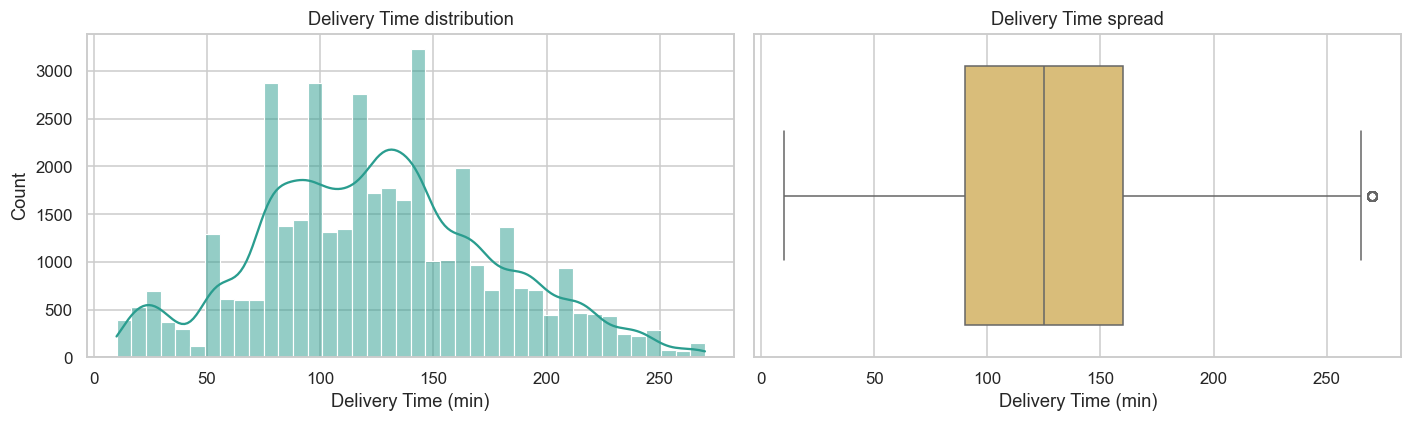

count    40153.000000
mean       125.077205
std         51.922413
min         10.000000
25%         90.000000
50%        125.000000
75%        160.000000
max        270.000000
Name: Delivery_Time, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(clean["Delivery_Time"], bins=40, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Delivery Time distribution")
axes[0].set_xlabel("Delivery Time (min)")

sns.boxplot(x=clean["Delivery_Time"], ax=axes[1], color="#e9c46a")
axes[1].set_title("Delivery Time spread")
axes[1].set_xlabel("Delivery Time (min)")
plt.tight_layout()
plt.show()

print(clean["Delivery_Time"].describe())

### Distribution of Delivery Time — Key Observations

- A typical delivery takes around 2 hours — the median sits right at about 125 minutes and the box (middle 50% of orders) runs from roughly 90 to 160 minutes.
- Delivery times stretch from about 10 minutes all the way out to 270, but most orders fall in the 75-175 minute band.
- The distribution is right-skewed — there is a longer tail toward the slow end (250+ min) than toward the fast end, so slow deliveries pull the average up.
- The density curve is bumpy rather than one smooth hump, with peaks near 80, 120, and 145 minutes — this hints that we are looking at several groups mixed together (traffic, area, time of day) rather than one uniform population, which is what we break apart in the next charts.
- The boxplot shows only a single outlier past the upper whisker, so the long tail is just "normal slow" deliveries, not freak cases — nothing extreme needs to be cleaned or excluded.
- **Bottom line:** delivery time is genuinely variable and slightly skewed slow, and that spread is real signal — it means the other variables in the dataset have something to explain.

### 5.2 Delivery time by categorical conditions

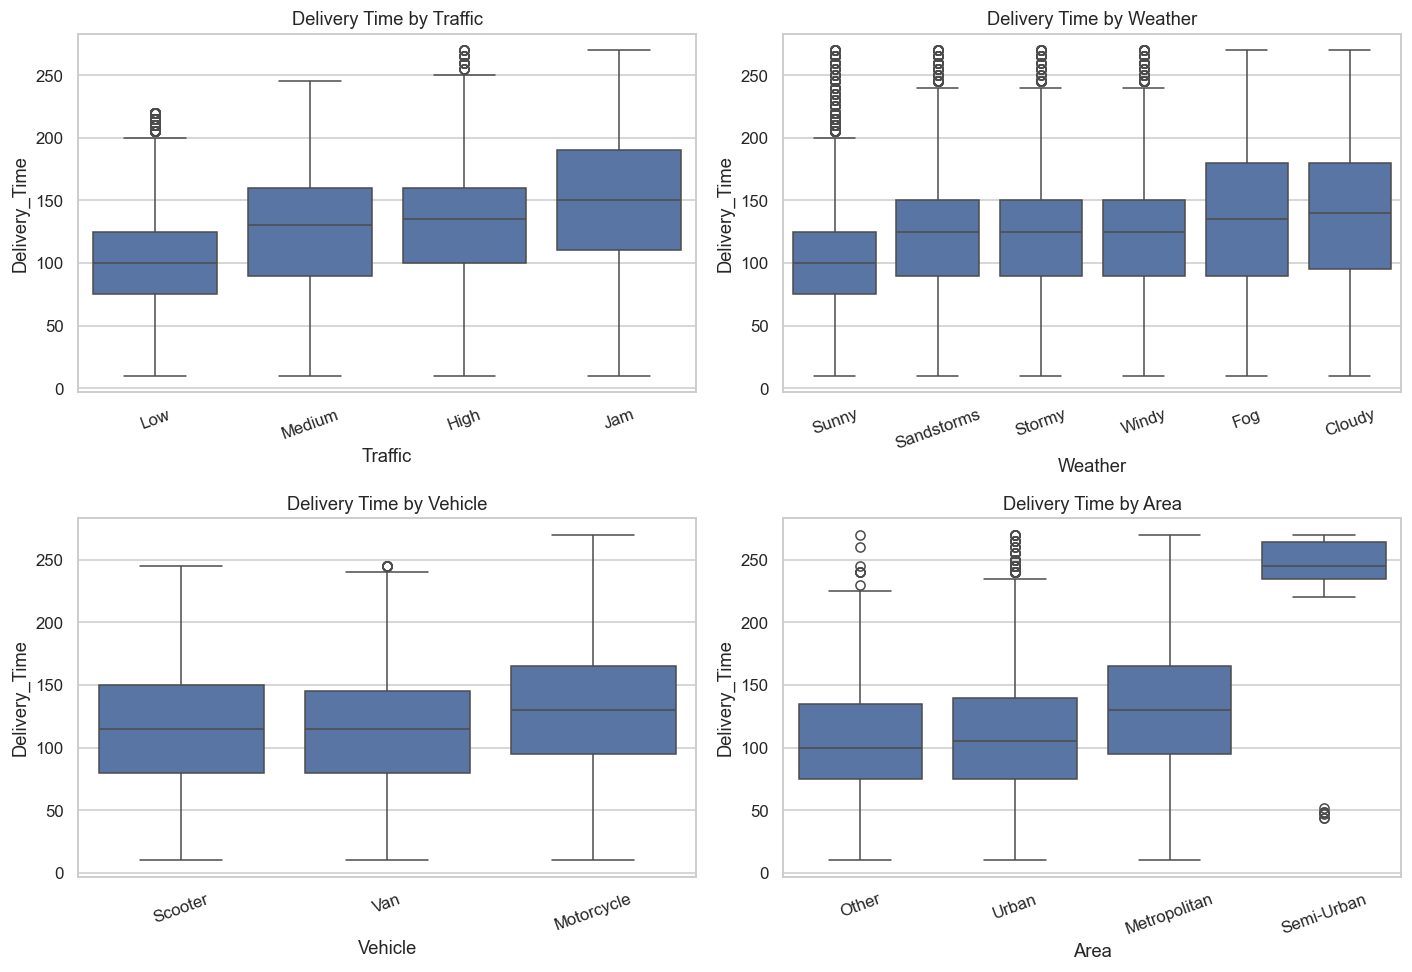

In [30]:
cats = ["Traffic", "Weather", "Vehicle", "Area"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cats):
    order = clean.groupby(col)["Delivery_Time"].median().sort_values().index
    sns.boxplot(data=clean, x=col, y="Delivery_Time", order=order, ax=ax)
    ax.set_title(f"Delivery Time by {col}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Delivery Time by Traffic, Weather, Vehicle & Area — Key Observations

- Traffic is the cleanest signal in the dataset — median delivery time climbs steadily from about 100 minutes in Low traffic, to ~130 in Medium, ~135 in High, and ~150 in Jam, exactly the monotonic pattern we would expect.
- Weather matters too, though less sharply — Sunny is clearly the fastest at around 100 minutes, while Fog and Cloudy are the slowest near 135-140, and the wider boxes on Fog/Cloudy show those conditions also make delivery time less predictable.
- Vehicle differences are modest — Scooter and Van are similar at roughly 115 minutes, while Motorcycle runs slower at about 130, possibly because motorcycles are dispatched on longer or more congested routes.
- Area has the single biggest surprise — Semi-Urban deliveries sit far above everything else, with a median near 245 minutes and a very tight box, versus 100-130 for the other area types.
- That Semi-Urban gap is so large and so consistent (note how narrow the box is) that it points to something structural — sparse address coverage, longer last-mile routes, or possibly a data artifact — and would be the first thing to investigate operationally.
- **Bottom line:** across all four charts, the conditions an order is delivered under matter more than the vehicle used — traffic and area type are the strongest categorical drivers of delivery time.

### 5.3 Distance vs. delivery time

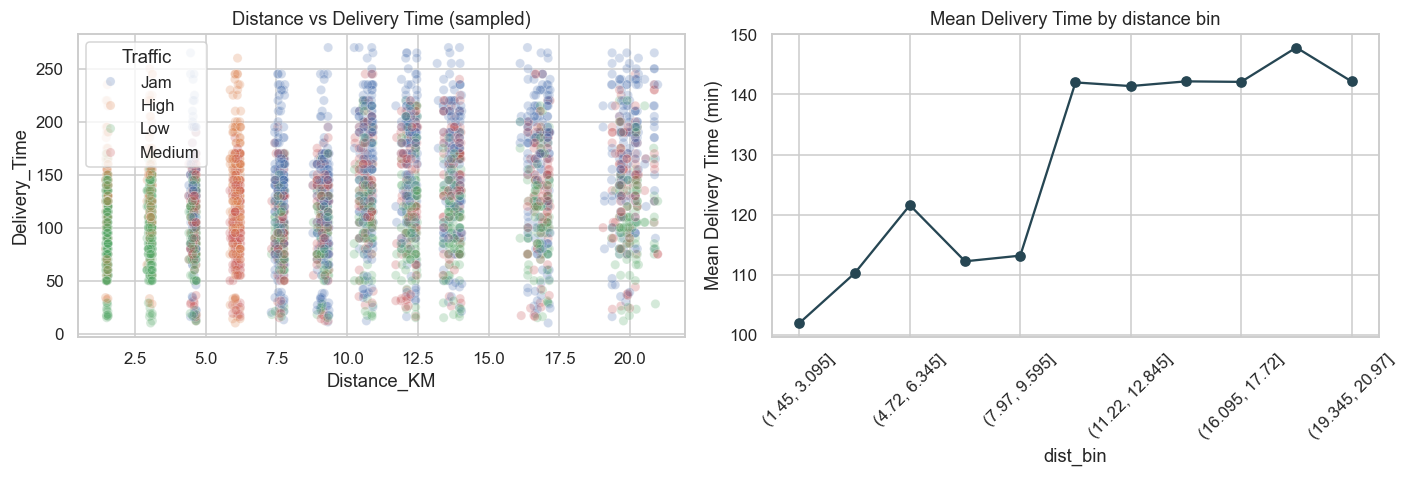

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(data=clean.sample(min(4000, len(clean)), random_state=0),
                x="Distance_KM", y="Delivery_Time", alpha=0.25,
                hue="Traffic", ax=axes[0])
axes[0].set_title("Distance vs Delivery Time (sampled)")

# Binned mean to show the trend clearly
clean["dist_bin"] = pd.cut(clean["Distance_KM"], bins=12)
binned = clean.groupby("dist_bin", observed=True)["Delivery_Time"].mean()
binned.plot(marker="o", ax=axes[1], color="#264653")
axes[1].set_title("Mean Delivery Time by distance bin")
axes[1].set_ylabel("Mean Delivery Time (min)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Distance vs Delivery Time — Key Observations

- Distance and delivery time move together — the binned chart shows mean delivery time rising from about 100 minutes for the shortest trips up to roughly 145 for the longest, confirming distance is a real factor.
- The relationship is not smooth though — delivery time jumps sharply between the ~7-10 KM and ~10-13 KM bins (from ~113 up to ~142 minutes) and then flattens out, so once trips pass a certain distance the time stops climbing much.
- That plateau suggests delivery time is capped by something other than distance on longer routes — likely traffic, batching, or route structure — rather than scaling linearly with how far the package travels.
- The raw scatter on the left is essentially a noisy vertical band — at any given distance, delivery times run the full range from under 50 minutes to over 250 — which tells us distance alone is a weak predictor.
- The Traffic colors in the scatter reinforce the earlier finding: green (Low) points cluster lower and blue (Jam) points cluster higher at the same distance, so traffic explains a lot of the vertical spread that distance cannot.
- **Bottom line:** distance matters but only modestly (correlation around 0.28) — it sets a rough floor for delivery time, while conditions like traffic drive most of the variation around it.

### 5.4 Time-of-day and day-of-week patterns

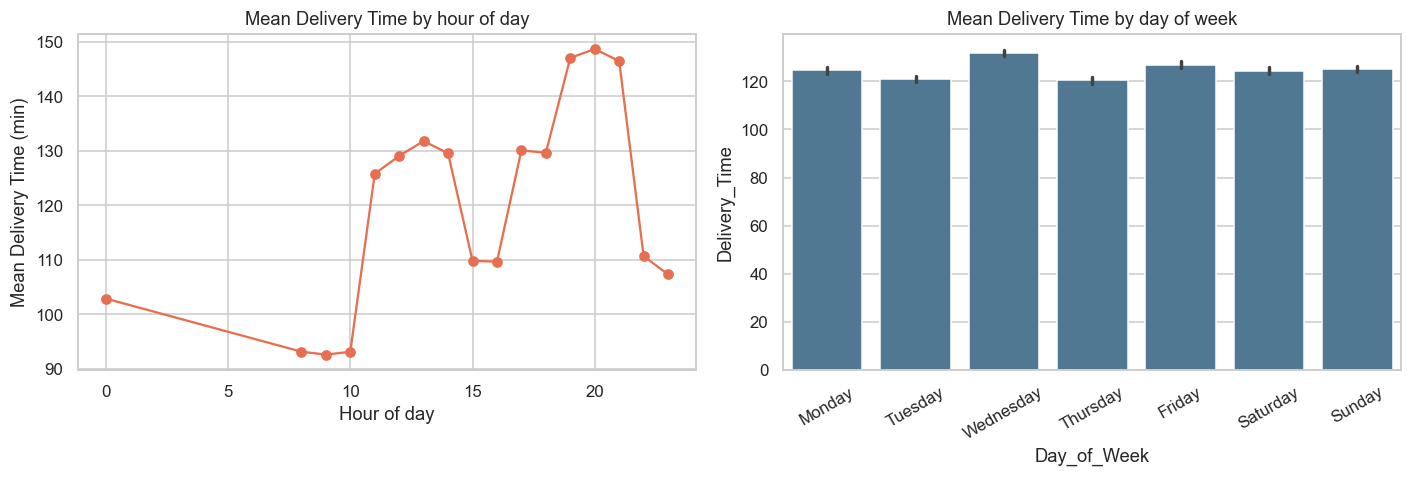

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

hourly = clean.groupby("Hour_of_Day")["Delivery_Time"].mean()
hourly.plot(marker="o", ax=axes[0], color="#e76f51")
axes[0].set_title("Mean Delivery Time by hour of day")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean Delivery Time (min)")

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
sns.barplot(data=clean, x="Day_of_Week", y="Delivery_Time",
            order=dow_order, ax=axes[1], color="#457b9d")
axes[1].set_title("Mean Delivery Time by day of week")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Time-of-Day & Day-of-Week Patterns — Key Observations

- There is a strong time-of-day pattern — mornings (8-10am) are the fastest at around 90 minutes, while the evening window of 7-9pm is the slowest at close to 150, a swing of roughly 60 minutes depending purely on when an order is placed.
- The hourly curve is not a smooth rise — it jumps in two steps: a sharp climb after 10am into a midday plateau (~125-130 min), a brief dip around 3-4pm back to ~110, and then a second climb into the evening peak.
- That midday dip and evening peak line up with real-world congestion — the slowest deliveries fall squarely in the evening rush hour, which is consistent with traffic being the main driver we saw earlier.
- Note the gap in early-morning hours (roughly 1-7am) — there are simply very few or no orders placed then, so the curve picks back up at hour 8.
- Day of week, by contrast, is essentially flat — every day averages between about 120 and 132 minutes, with Wednesday only marginally the slowest and the error bars overlapping across all seven days.
- **Bottom line:** when an order is placed during the day matters a great deal, but which day of the week it falls on barely moves delivery time at all.

### 5.5 Volume and delivery time by city

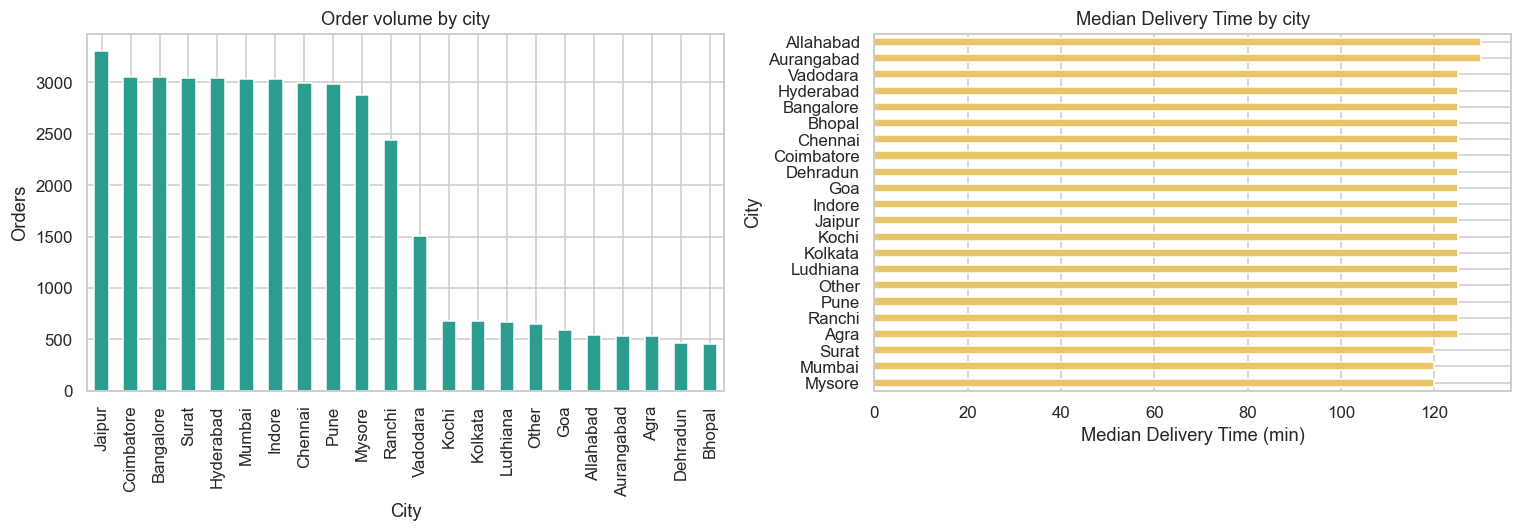

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clean["City"].value_counts().plot(kind="bar", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Order volume by city")
axes[0].set_ylabel("Orders")

city_med = clean.groupby("City")["Delivery_Time"].median().sort_values()
city_med.plot(kind="barh", ax=axes[1], color="#e9c46a")
axes[1].set_title("Median Delivery Time by city")
axes[1].set_xlabel("Median Delivery Time (min)")
plt.tight_layout()
plt.show()

### Order Volume & Delivery Time by City — Key Observations

- Order volume is heavily concentrated in the big metros — Jaipur, Coimbatore, Bangalore, Surat, Hyderabad, Mumbai, Indore, Chennai, and Pune each carry roughly 3,000 orders, while the remaining cities drop off sharply to under ~700 each.
- There is a clear two-tier split in the volume chart — about ten high-volume cities, then a long tail of smaller markets (Kochi, Kolkata, Ludhiana, Goa, Agra, Bhopal and others) that contribute only a few hundred orders apiece.
- Median delivery time, by contrast, is remarkably flat across cities — nearly every city sits in a tight band right around 120-130 minutes, with no city standing out as dramatically faster or slower.
- Allahabad and Aurangabad are marginally the slowest and Mysore, Surat, and Mumbai marginally the fastest, but the spread between the slowest and fastest city is only about 10 minutes — small enough to treat as noise.
- One practical note: the high-volume cities are where any operational improvement would have the largest total impact, simply because that is where most of the deliveries happen.
- **Bottom line:** the city an order is placed in tells us a lot about how much volume to expect, but very little about how long a delivery will take — the conditions inside the city (traffic, area type, time of day) matter far more than the city label itself.

### 5.6 Agent age & rating vs. delivery time

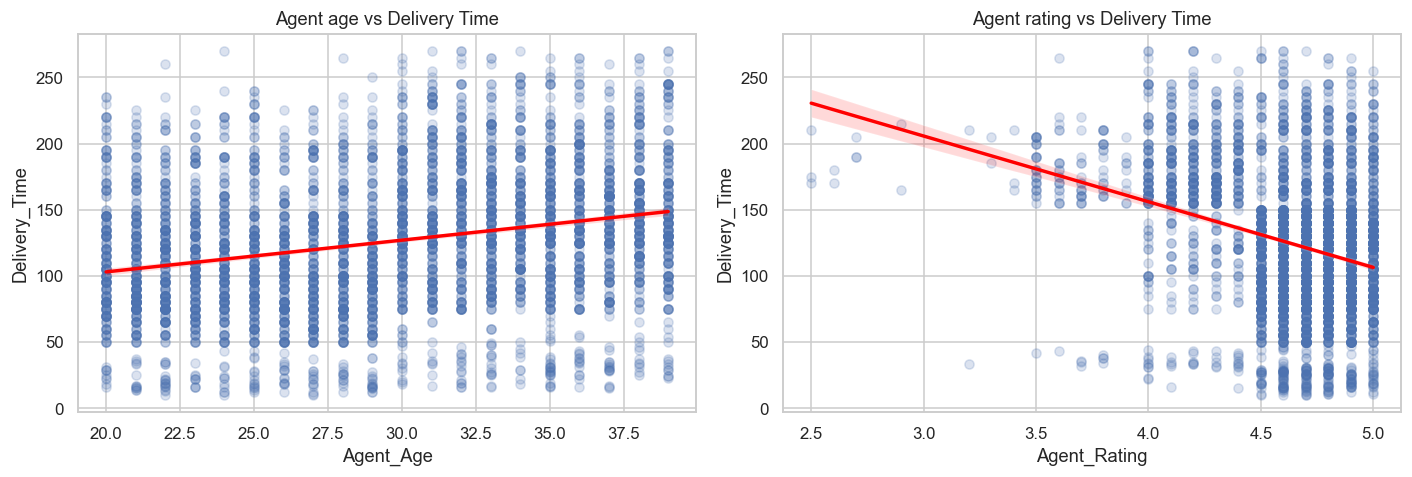

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.regplot(data=clean.sample(min(4000, len(clean)), random_state=0),
            x="Agent_Age", y="Delivery_Time",
            scatter_kws={"alpha": 0.2}, line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("Agent age vs Delivery Time")

sns.regplot(data=clean.dropna(subset=["Agent_Rating"]).sample(
                min(4000, clean["Agent_Rating"].notna().sum()), random_state=0),
            x="Agent_Rating", y="Delivery_Time",
            scatter_kws={"alpha": 0.2}, line_kws={"color": "red"}, ax=axes[1])
axes[1].set_title("Agent rating vs Delivery Time")
plt.tight_layout()
plt.show()

### Agent Age & Rating — Key Observations

- Agent rating is the strongest agent-level signal — the regression line slopes clearly downward, from a predicted ~230 minutes at a 2.5 rating to ~105 minutes at a 5.0 rating, a correlation of about -0.31.
- Most agents are clustered at the high end of the rating scale (4.0-5.0), and that is also where delivery times are lowest and most variable. The handful of low-rated agents (below ~3.5) almost all show long delivery times.
- Agent age shows the opposite, weaker trend — the line slopes gently upward, with mean delivery time rising from roughly 100 minutes for agents in their early 20s to about 150 for agents near 40, a correlation of around +0.26.
- We are cautious reading the age relationship too literally — age is likely standing in for something else (route assignments, region, or vehicle type) rather than older agents being slower on their own.
- Both scatters are very wide vertical bands — at any single age or rating, delivery times still run the full range from under 50 minutes to over 250 — so neither variable is a strong standalone predictor of an individual delivery.
- **Bottom line:** agent rating is a modest but real predictor of speed and is the more trustworthy of the two, while age correlates with delivery time but probably only indirectly.

### 5.7 Correlation heatmap (numeric features)

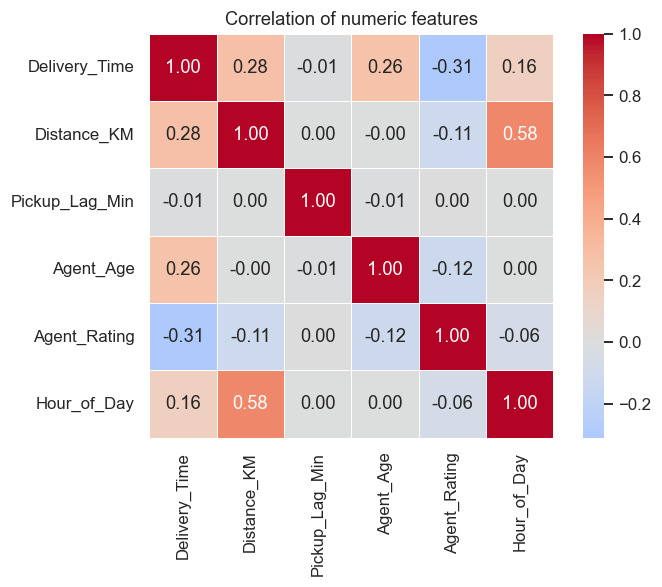

In [26]:
num_cols = ["Delivery_Time", "Distance_KM", "Pickup_Lag_Min",
            "Agent_Age", "Agent_Rating", "Hour_of_Day"]
corr = clean[num_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5)
plt.title("Correlation of numeric features")
plt.tight_layout()
plt.show()

### Correlation Heatmap — Key Observations

- No single numeric feature dominates delivery time. The strongest correlations with Delivery_Time are only modest: Agent_Rating at -0.31, Distance_KM at +0.28, and Agent_Age at +0.26.
- The signs all make sense — higher-rated agents deliver faster (negative), while longer distances and older agents are associated with slower deliveries (positive).
- Pickup_Lag_Min has essentially zero correlation with Delivery_Time (-0.01). The few minutes a store takes to hand the order over tells us nothing about how long the trip itself will take.
- The most notable off-diagonal value is Distance_KM vs Hour_of_Day at +0.58 — longer-distance orders tend to be placed later in the day, which likely explains part of why evening deliveries were the slowest in chart 5.4.
- That distance-hour link is a mild collinearity worth remembering — if these features were ever used together in a model, some of their explanatory power would overlap rather than add up.
- The remaining feature pairs are all weak (near 0), so the numeric variables are mostly independent of one another.
- **Bottom line:** the heatmap confirms the theme of the whole EDA — delivery time is not driven by any one number, but by a combination of distance, agent quality, and timing, with the categorical conditions (traffic and area) from the earlier charts carrying the rest of the explanation.

### 5.8 Takeaways

A few patterns typically stand out from the charts above:

- **Traffic** is the strongest categorical driver — `Jam` conditions push
  delivery time up sharply.
- **Distance** has a clear positive relationship with delivery time, though it
  explains less of the variance than traffic.
- **Vehicle** and **Area** matter at the margin (e.g. denser metropolitan areas).
- **Agent age/rating** show only weak correlations with delivery time.


 ## Conclusion

### Data Cleaning Summary
We started with a raw file of 43,739 delivery records that was not analysis ready. The cleaning process did the following:
- Stripped trailing whitespace from every categorical column and standardized casing (motorcycle to Motorcycle) and spelling (Metropolitian to Metropolitan)
- Converted the literal string "NaN" - which was being used as a placeholder - into real missing values
- Dropped 91 rows missing Weather, Traffic, or Order_Time, and removed rows with an impossible Agent_Rating above 5
- Fixed the GPS coordinates by taking absolute values to correct sign-flipped store locations, then dropped roughly 3,500 rows whose coordinates were near-zero placeholder values
- The cleaned file ended with 40,153 rows - about 3,586 rows (8%) were removed, almost all of them failed-geocode coordinate rows

### Feature Engineering Summary
On top of cleaning, we engineered new columns the raw data did not have: proper Order and Pickup datetimes (with a fix for pickups that crossed midnight), the pickup lag in minutes, calendar fields (day of week, hour of day, week of year), the great-circle Distance_KM between store and drop via the Haversine formula, and a City label derived from the nearest major Indian city. This took the dataset from 16 columns up to 24.

### Key Findings
- A typical delivery takes about 125 minutes (just over 2 hours), with times ranging from 10 to 270 minutes and a slight skew toward slower deliveries
- Traffic is the single clearest driver - median delivery time rises steadily from ~100 minutes in Low traffic to ~150 in Jam traffic
- Area type produced the biggest surprise - Semi-Urban deliveries take far longer (median ~245 minutes) than any other area, a gap large enough to warrant its own operational investigation
- Time of day matters a lot - mornings are fastest (~90 min) and the 7-9pm evening window is slowest (~150 min) - while the day of the week barely matters at all
- Distance has a real but modest effect (correlation ~0.28) and tends to plateau on longer routes rather than scaling linearly
- Among agent attributes, rating is the more meaningful signal (~-0.31, higher-rated agents are faster); age correlates positively but likely only indirectly
- No single numeric feature d

## 6. Save the cleaned dataset

In [27]:
# Drop the helper column added for plotting before exporting
export = clean.drop(columns=["dist_bin"], errors="ignore")
export.to_csv(CLEAN_PATH, index=False)
print(f"Saved {len(export):,} rows x {export.shape[1]} columns -> {CLEAN_PATH}")
export.head()

Saved 40,153 rows x 24 columns -> amazon_delivery_clean.csv


,Order_ID,Order_Datetime,Pickup_Datetime,Order_Date,Order_Time,Pickup_Time,Day_of_Week,Hour_of_Day,Week_of_Year,Pickup_Lag_Min,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,City,Distance_KM,Weather,Traffic,Vehicle,Area,Category,Delivery_Time
0,ialx566343618,2022-03-19 11:30:00,2022-03-19 11:45:00,2022-03-19,11:30:00,11:45:00,Saturday,11,11,15.0,37,4.9,22.745049,75.892471,22.765049,75.912471,Indore,3.03,Sunny,High,Motorcycle,Urban,Clothing,120
1,akqg208421122,2022-03-25 19:45:00,2022-03-25 19:50:00,2022-03-25,19:45:00,19:50:00,Friday,19,12,5.0,34,4.5,12.913041,77.683237,13.043041,77.813237,Bangalore,20.18,Stormy,Jam,Scooter,Metropolitan,Electronics,165
2,njpu434582536,2022-03-19 08:30:00,2022-03-19 08:45:00,2022-03-19,08:30:00,08:45:00,Saturday,8,11,15.0,23,4.4,12.914264,77.678400,12.924264,77.688400,Bangalore,1.55,Sandstorms,Low,Motorcycle,Urban,Sports,130
3,rjto796129700,2022-04-05 18:00:00,2022-04-05 18:10:00,2022-04-05,18:00:00,18:10:00,Tuesday,18,14,10.0,38,4.7,11.003669,76.976494,11.053669,77.026494,Coimbatore,7.79,Sunny,Medium,Motorcycle,Metropolitan,Cosmetics,105
4,zguw716275638,2022-03-26 13:30:00,2022-03-26 13:45:00,2022-03-26,13:30:00,13:45:00,Saturday,13,12,15.0,32,4.6,12.972793,80.249982,13.012793,80.289982,Chennai,6.21,Cloudy,High,Scooter,Metropolitan,Toys,150
